In [72]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
import re

from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit

from matplotlib.patches import Patch



In [42]:
glomeruli = ["L9","L8","L7","L6","L5","L4","L3","L2","L1",
             "R1","R2","R3","R4","R5","R6","R7","R8","R9"]

In [43]:
files = {
    "fly1": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly1.csv",
    "fly2": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly2.csv",
    "fly100": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly2.csv"
}

In [44]:
original = {
    name: pd.read_csv(path, index_col=0).assign(glomerulus=glomeruli)[
        ["glomerulus","mean_red","mean_green","total_red","total_green"]
    ]
    for name, path in files.items()
}

In [45]:
original["fly1"]

,glomerulus,mean_red,mean_green,total_red,total_green
0,L9,848.954201,73.941009,4.022761e+08,35036873.0
1,L8,955.666263,71.846106,6.839656e+08,51419899.0
2,L7,846.518062,63.483875,5.785502e+08,43387864.0
3,L6,888.429529,59.067325,3.275302e+08,21775878.0
4,L5,849.205255,61.282188,3.313701e+08,23913045.0
5,L4,769.550523,56.653493,2.707810e+08,19934608.0
6,L3,1429.598217,80.145079,2.727652e+09,152915609.0
7,L2,615.791312,45.274323,2.307241e+08,16963338.0
8,L1,723.791525,54.077473,4.096240e+08,30604713.0
9,R1,796.183173,52.765766,1.056030e+09,69986718.0


In [46]:
# another (previous) way to open all cvs one by one
'''
fly1 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly1.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]
fly2 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly2.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]
'''


'\nfly1 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly1.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]\nfly2 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly2.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]\n'

In [47]:
fly_subtype = pd.DataFrame({
    'fly': ['fly1','fly2', "fly100"],
    'subtype': ['L3R6','L4R5','L1L9R8']
})

In [48]:
tokens = fly_subtype['subtype'].str.findall(r'[LR]\d+')

# 2. Figure out the maximum number of tokens any row has
max_parts = tokens.map(len).max()

# 3. Create column names dynamically (part1, part2, …)
col_names = [f'part{i+1}' for i in range(max_parts)]

# 4. “Unpack” the lists of tokens into separate columns
fly_subtype[col_names] = pd.DataFrame(tokens.tolist(), index=fly_subtype.index)

fly_subtype

,fly,subtype,part1,part2,part3
0,fly1,L3R6,L3,R6,None
1,fly2,L4R5,L4,R5,None
2,fly100,L1L9R8,L1,L9,R8


In [49]:
brains_with_3glo = {}
brains_with_2glo = {}

for _, row in fly_subtype.iterrows():
    fly_name = row["fly"]
    subtype  = row["subtype"]

    if len(subtype) == 4:
        brains_with_2glo[fly_name] = original[fly_name]
    else:
        brains_with_3glo[fly_name] = original[fly_name]

# to check
list(brains_with_3glo.keys())
#list(brains_with_2glo.keys())

['fly100']

In [50]:
def split_halves(source_dict):
    halves = {}
    for name, df in source_dict.items():
        df_first  = df.iloc[:9].reset_index(drop=True)
        df_second = df.iloc[9:].reset_index(drop=True)
        halves[f"{name}_L"] = df_first
        halves[f"{name}_R"] = df_second
    return halves

brains_with_2glo_halves = split_halves(brains_with_2glo)
brains_with_3glo_halves = split_halves(brains_with_3glo)

In [52]:
brains_with_3glo_halves['fly100_L']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L9,427.134735,85.518306,2.149949e+08,43044955.0
1,L8,558.450000,96.511439,7.762762e+08,134156209.0
2,L7,454.020630,81.831272,6.092880e+08,109816176.0
3,L6,311.554881,40.946779,4.627556e+07,6081866.0
4,L5,494.719482,52.949216,1.444101e+08,15456035.0
5,L4,672.119339,72.882256,1.132133e+09,122764548.0
6,L3,367.928993,41.314100,9.149621e+07,10273949.0
7,L2,381.503379,26.438359,1.159133e+08,8032846.0
8,L1,277.857397,38.672564,6.744210e+07,9386682.0


In [54]:
list(brains_with_3glo_halves.keys())

['fly100_L', 'fly100_R']

In [64]:
# split left and right bridge for 2glo brains:

parts_lookup = fly_subtype.set_index("fly")[["part1", "part2"]].to_dict("index")

reordered_2glo_halves = {}

for name, df in brains_with_2glo_halves.items():
    base_name = name.split("_")[0]                   # e.g., "fly1_L" -> "fly1"
    column_to_look = "part1" if "_L" in name else "part2"

    parts = parts_lookup.get(base_name)
    if parts is None or pd.isna(parts.get(column_to_look, None)):
        continue

    center = parts[column_to_look]                   # e.g., "R4" or "L3"

    # find the row index where glomerulus == center
    idxs = df.index[df["glomerulus"] == center]
    if len(idxs) == 0:
        continue
    current_idx = int(idxs[0])

    # put center on the 5th row (0-based index 4)
    target_idx = 4
    shift = target_idx - current_idx

    # roll row order safely
    order = np.roll(np.arange(len(df)), shift)
    df_reordered = df.iloc[order].reset_index(drop=True)

    reordered_2glo_halves[f"{name}_reordered"] = df_reordered


In [65]:
# split left and right bridge for 3glo brains:


parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

reordered_3glo_halves = {}  # output for 3-glom brains

for name, df in brains_with_3glo_halves.items():
    # parse fly base name and side ("_L" or "_R" at the end is assumed)
    if "_" not in name:
        continue
    fly_base, side = name.rsplit("_", 1)            # fly1_L --> L
    side = side.upper()
    if side not in {"L", "R"}:
        continue

    # lookup this fly’s parts
    parts = parts_lookup.get(fly_base)              # makes a dictionary for this fly* {'part1': 'L3', 'part2': 'R6', 'part3': None} where "part*" is the key.
    if parts is None:
        continue

    # 2) collect all centers that match the side (L or R) across part1/part2/part3
    raw_parts = [parts.get("part1"), parts.get("part2"), parts.get("part3")]
    centers = []
    for p in raw_parts:
        if isinstance(p, str):
            s = p.strip()                           # just remove any blankspace
            if s and s.lower() != "none" and s.upper().startswith(side):
                centers.append(s)

    if not centers:
        # nothing to center on
        continue

    # 3) preference rule when two centers exist:
    #    prefer "<side>1" over "<side>9" (i.e., L1 over L9, R1 over R9).
    preferred = None
    if (side + "1") in centers:
        preferred = side + "1"
    elif (side + "9") in centers:
        preferred = side + "9"
    else:
        # if neither specific preference is present, just take the first
        preferred = centers[0]

    center = preferred  # the label we will align to row 5 (index 4)

    # find the current index of the chosen center in this half
    idxs = df.index[df["glomerulus"].astype(str) == center]
    if len(idxs) == 0:
        # if the label isn't present in this half, skip
        continue
    current_idx = int(idxs[0])

    # place center on the 5th row (0-based index 4)
    target_idx = 4
    shift = target_idx - current_idx

    # roll row order safely (preserve columns/dtypes)
    order = np.roll(np.arange(len(df)), shift)
    df_reordered = df.iloc[order].reset_index(drop=True)

    reordered_3glo_halves[f"{name}_reordered"] = df_reordered

In [69]:
reordered_3glo_halves['fly100_R_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R4,425.790373,59.608685,2.716866e+08,38034871.0
1,R5,677.395411,89.498695,1.500224e+09,198212313.0
2,R6,468.295587,68.206804,3.822477e+08,55674008.0
3,R7,436.779988,80.147440,2.973319e+08,54559248.0
4,R8,436.858658,76.262017,4.402841e+08,76859987.0
5,R9,458.098518,79.661449,2.523587e+08,43884138.0
6,R1,412.160457,52.937906,3.927172e+08,50440613.0
7,R2,426.297191,66.404253,4.425114e+08,68929939.0
8,R3,429.254956,62.565032,3.062511e+08,44636897.0


In [70]:
# maybe combine reordered_2glo_halves and reordered_3glo_halves into a reordered_dfs
reordered_halves_all = {**reordered_2glo_halves, **reordered_3glo_halves}
list(reordered_halves_all.keys())

['fly1_L_reordered',
 'fly1_R_reordered',
 'fly2_L_reordered',
 'fly2_R_reordered',
 'fly100_L_reordered',
 'fly100_R_reordered']

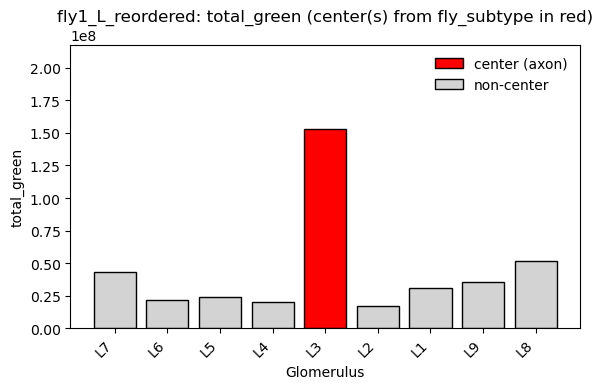

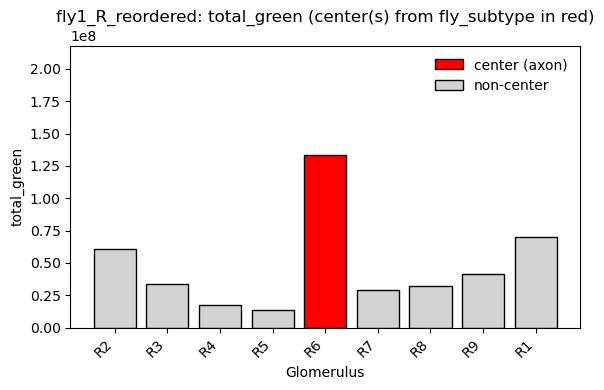

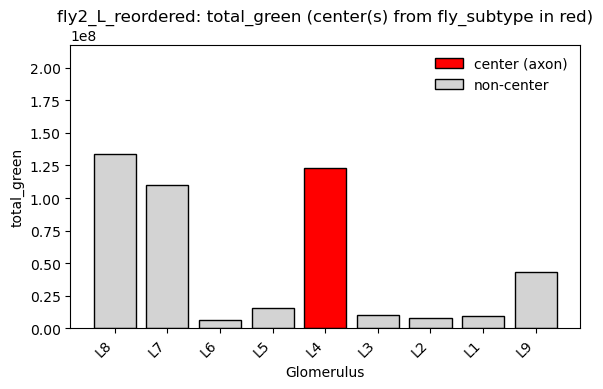

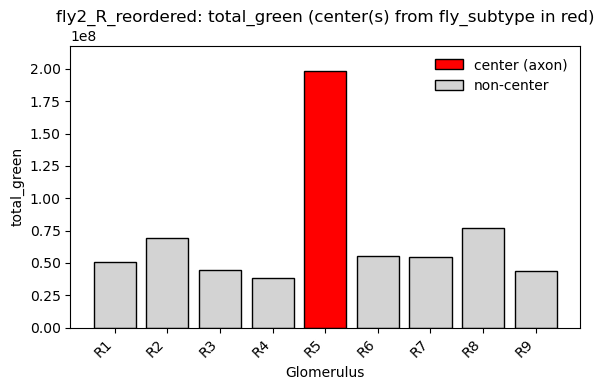

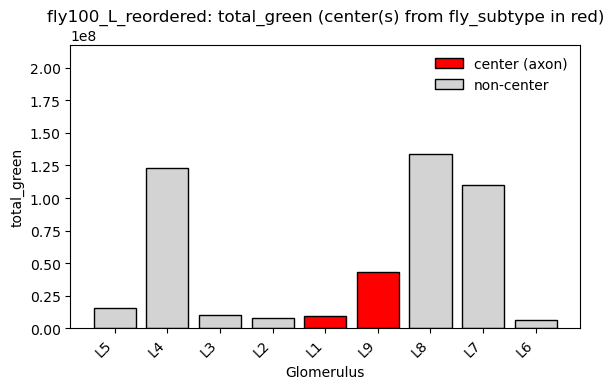

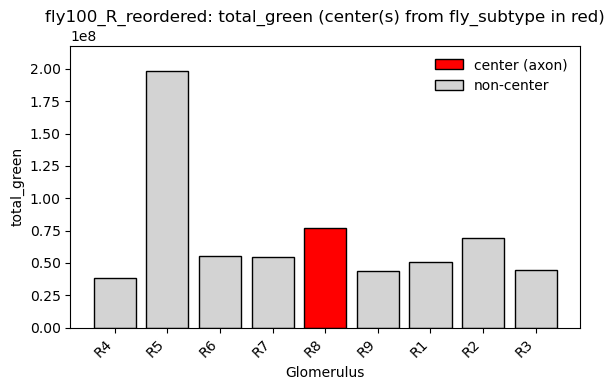

In [81]:
# make the histograms


# -----------------------
# Helpers / lookups
# -----------------------
def _is_present(x) -> bool:
    return isinstance(x, str) and x.strip() and x.strip().lower() != "none"

# Canonicalize labels like "PB(L3)" or " l3 " -> "L3"
def canon(s: object) -> str:
    s = str(s).strip().upper()
    m = re.search(r'[LR]\d+', s)
    return m.group(0) if m else s

# Ensure part3 exists (so code works for both 2- and 3-glo)
if "part3" not in fly_subtype.columns:
    fly_subtype = fly_subtype.assign(part3=np.nan)

# Fast lookup: {"fly1": {"part1": "...", "part2": "...", "part3": "..."}}
parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

# -----------------------
# The missing function
# -----------------------
def get_centers_for_table(table_name: str) -> list[str]:
    """
    Return the list of center labels (e.g., ["L3"] or ["L1","L9"]) for a table name in
    `reordered_halves_all`. Works for both 2-glo and 3-glo based on fly_subtype.
    Table name format can be 'flyN_L', 'flyN_R', 'flyN_L_reordered', etc.
    """
    # Parse "<fly>_<side>" (side is final L/R before any extra suffixes)
    m = re.match(r'^(.+?)_([LR])(?:_.*)?$', table_name, flags=re.IGNORECASE)
    if not m:
        return []
    fly_base, side = m.group(1), m.group(2).upper()

    row = parts_lookup.get(fly_base)
    if row is None:
        return []

    p1, p2, p3 = row.get("part1"), row.get("part2"), row.get("part3")
    is_3glo = _is_present(p3)

    if not is_3glo:
        # ----- 2-glo logic -----
        if side == "L":
            center = p1 if _is_present(p1) else None
        else:
            center = p2 if _is_present(p2) else None
        return [center] if center else []

    # ----- 3-glo logic -----
    candidates = [p for p in (p1, p2, p3) if _is_present(p)]
    centers = [c.strip() for c in candidates if c.strip().upper().startswith(side)]
    return centers

# -----------------------
# Plot with shared y-axis
# -----------------------
# 1) find a common y max across all plots
global_max = 0.0
for _, df in reordered_halves_all.items():
    y = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()
    if y.size:
        global_max = max(global_max, float(np.nanmax(y)))
ymax = global_max * 1.1 if global_max > 0 else 1.0  # margin

# 2) make each plot; color centers red after canonicalizing labels
for name, df in reordered_halves_all.items():
    centers_raw = get_centers_for_table(name)
    centers_set = {canon(c) for c in centers_raw if c is not None}

    gloms_raw = df["glomerulus"].astype(str).tolist()
    gloms_can = [canon(g) for g in gloms_raw]

    colors = ["red" if g in centers_set else "lightgray" for g in gloms_can]

    # Optional sanity check:
    # if "red" not in colors:
    #     print(f"[warn] no centers colored for {name}; centers={sorted(centers_set)}; gloms={gloms_can}")

    y = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()

    plt.figure(figsize=(6, 4))
    plt.bar(gloms_raw, y, color=colors, edgecolor="black")
    plt.title(f"{name}: total_green (center(s) from fly_subtype in red)")
    plt.xlabel("Glomerulus")
    plt.ylabel("total_green")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, ymax)

    plt.legend(
        handles=[
            Patch(facecolor="red", edgecolor="black", label="center (axon)"),
            Patch(facecolor="lightgray", edgecolor="black", label="non-center"),
        ],
        loc="upper right",
        frameon=False,
    )
    
    plt.tight_layout()
    plt.show()

In [ ]:
reordered_3glo_halves['fly100_R_reordered']